# MdnC ConSurf Curation Pipeline

**Goal.** Build a *clean, microviridin-specific* homolog set for MdnC (the ester/lactone-forming
microviridin macrocyclase, PDB **5IG9**) so that a ConSurf run can show the α7 leader-recognition
residues **Glu191 / Asp192 / Asn195** as evolutionarily conserved.

**Why this notebook exists.** An earlier ConSurf run failed because the homolog set was dominated by
distant, non-microviridin ATP-grasp ligases. This pipeline fixes that in stages. The key lesson we
learned partway through: **the HMM classifies by chemistry (ester vs amide), not by *microviridin
membership*.** Passing the ester-former HMM threshold is necessary but *not sufficient* — the pool is
~58% non-cyanobacterial graspetide ligases that share the fold but diverge at the α7 residues. So a
**taxonomic filter to Cyanobacteria** (Section D) is now a required step, and the final set is defined
by a **monophyletic clade** in a phylogenetic tree (Section F), not by the HMM threshold alone.

### Revised pipeline order
1. **B.** HMM classification — separate ester-formers (MvdD / MdnC-type) from amide-formers (MvdC / MdnB-type)
2. **C.** Validation — orthogonal (RODEO column), cross-check (old pairwise method), and the α7 consensus panel
3. **D.** **NEW: taxonomic filter to Cyanobacteria** — the decontamination step the HMM couldn't do
4. **E.** Merge with the BLAST-window set + CD-HIT deduplication
5. **F.** MAFFT alignment → IQ-TREE clade selection → ConSurf

*Jargon is defined on first use throughout.*

## 0 — Setup & configuration

Set the paths and the Entrez email once. `DATA` is where all intermediate files live; adjust it to match
your machine (from your earlier runs it resolved to `../data`).

In [1]:
import subprocess
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

from Bio import Entrez, SeqIO, SearchIO, AlignIO
from Bio.Align import PairwiseAligner, substitution_matrices

# --- paths (adjust to your machine) ---
DATA = Path("../data")                      # where intermediate files are written/read
RODEO_XLSX = DATA / "Ramesh_Rodeo_data.xlsx"  # the RODEO graspetide spreadsheet (Ramesh et al. 2021)
DATA.mkdir(parents=True, exist_ok=True)

# --- NCBI Entrez (required for efetch) ---
Entrez.email = "phamminh1@ufl.edu"

# combined two-model HMM database (built in B.2)
hmm_db = DATA / "mvd_families.hmm"

## A — Build the RODEO Group-1 pool and the taxonomy maps

The RODEO spreadsheet (`Precursors` sheet) has one row per graspetide gene cluster, with the two ester/amide
ligase accessions (`ATP grasp ligase-1/-2 accession ID`) **and full taxonomy** (`Superkingdom … Genus`).
We build three things from it, all keyed on the versioned accession (e.g. `AGH69798.1`):

- `g1_accessions` — the 824 unique Group-1 ligase accessions (this *is* your `rodeo_g1` pool)
- `acc2column` — accession → RODEO column (`L1`/`L2`), used for the orthogonal validation in C.1
- `acc2phylum` — accession → phylum, used for the taxonomic filter in D

> **Gotcha:** the raw header is `'Phylum '` with a **trailing space**, and the sheet uses the *old* phylum
> names (`Cyanobacteria`, `Bacteroidetes`), not the newer `Cyanobacteriota`/`Bacteroidota`. We strip the
> header whitespace and match the string that's actually present.

In [2]:
sheet = pd.read_excel(RODEO_XLSX, sheet_name="Precursors")
sheet.columns = [c.strip() for c in sheet.columns]     # fixes 'Phylum ' trailing space
g1_rows = sheet[sheet["Graspetide group"] == 1]

L1_COL = "ATP grasp ligase-1 accession ID"
L2_COL = "ATP grasp ligase-2 accession ID"

g1_accessions = []
acc2column = {}
acc2phylum = {}
for _, r in g1_rows.iterrows():
    for tag, col in [("L1", L1_COL), ("L2", L2_COL)]:
        acc = r[col]
        if pd.notna(acc) and str(acc).strip():
            acc = str(acc).strip()
            if acc not in acc2column:          # first occurrence wins, preserves order
                g1_accessions.append(acc)
            acc2column[acc] = tag
            acc2phylum[acc] = r["Phylum"]

print(f"Group-1 unique ligase accessions: {len(g1_accessions)}")
print("Phylum breakdown of the whole pool:")
print(Counter(acc2phylum[a] for a in g1_accessions))

Group-1 unique ligase accessions: 824
Phylum breakdown of the whole pool:
Counter({'Bacteroidetes': 402, 'Cyanobacteria': 343, 'Proteobacteria': 71, 'Acidobacteria': 4, 'Planctomycetes': 2, 'uncultured': 2})


Load the sequences. If you already have `rodeo_g1.fasta` on disk (from earlier work), we reuse it so the
order matches your previous runs; otherwise we batch-fetch from NCBI. Either way we (re)write `rodeo_fasta`
**from `rodeo_g1`** so the scanned file and the record list are guaranteed to hold the same sequences in the
same order — this is what keeps `labels` aligned to `rodeo_g1` for the rest of the notebook.

In [3]:
rodeo_fasta = DATA / "rodeo_g1.fasta"

if rodeo_fasta.exists():
    rodeo_g1 = list(SeqIO.parse(rodeo_fasta, "fasta"))
else:
    # batch-fetch in chunks 
    records = []
    CHUNK = 200
    for i in range(0, len(g1_accessions), CHUNK):
        ids = ",".join(g1_accessions[i:i+CHUNK])
        h = Entrez.efetch(db="protein", id=ids, rettype="fasta", retmode="text")
        records.extend(SeqIO.parse(h, "fasta"))
        h.close()
    rodeo_g1 = records

# rewrite rodeo_fasta FROM rodeo_g1 so scan-file and record-list can never drift apart
SeqIO.write(rodeo_g1, rodeo_fasta, "fasta")
print(f"rodeo_g1: {len(rodeo_g1)} sequences")

rodeo_g1: 824 sequences


## B.2 — Combine and press the two HMM models

We search two profile HMMs at once: **TIGR04184** (model `NAME = ATPgraspMvdD`, the ester/lactone-formers →
MdnC-type) and **TIGR04185** (model `NAME = ATPgraspMvdC`, the amide/lactam-formers → MdnB-type). They live
concatenated in one file, `mvd_families.hmm`. `hmmpress` builds the binary index files (`.h3m/.h3i/.h3f/.h3p`)
that `hmmscan` actually reads.

> **The naming trap that follows us everywhere:** the string `hmmscan` reports for each hit is the model's
> **NAME** (`ATPgraspMvdD` / `ATPgraspMvdC`), **not** the accession (`TIGR04184` / `TIGR04185`). All parsing
> below branches on the NAME. Also note the cross-over: Mvd**D** = Mdn**C** (ester), Mvd**C** = Mdn**B** (amide).

In [4]:
# delete stale index files first (hmmpress refuses to overwrite them)
for ext in [".h3m", ".h3i", ".h3f", ".h3p"]:
    idx = hmm_db.with_suffix(hmm_db.suffix + ext)   # -> mvd_families.hmm.h3m, etc.
    if idx.exists():
        idx.unlink()

subprocess.run(["hmmpress", str(hmm_db)], check=True)
print(open(hmm_db).read()[:400])   # expect: NAME ATPgraspMvdD ... GA 475 475

Working...    done.
Pressed and indexed 2 HMMs (2 names and 2 accessions).
Models pressed into binary file:   ../data/mvd_families.hmm.h3m
SSI index for binary model file:   ../data/mvd_families.hmm.h3i
Profiles (MSV part) pressed into:  ../data/mvd_families.hmm.h3f
Profiles (remainder) pressed into: ../data/mvd_families.hmm.h3p
HMMER3/f [3.1b2 | February 2015]
NAME  ATPgraspMvdD
ACC   TIGR04184.1
DESC  MvdD family ATP-grasp ribosomal peptide maturase
LENG  321
ALPH  amino
RF    no
MM    no
CONS  yes
CS    no
MAP   yes
DATE  Fri Nov  2 18:34:33 2018
NSEQ  8
EFFN  0.683594
CKSUM 1223935159
GA    475 475
TC    475 475
NC    450 450
STATS LOCAL MSV      -11.2292  0.70078
STATS LOCAL VITERBI  -11.9477  0.70078
STATS LOCAL FOR


## B.3 — Positive control

Two hand-picked sequences with known chemistry: `WP_012265553` (ester) and `WP_012265554` (amide). We want
each to score highest on its own model, with the wrong-model score far below. **No `--cut_ga` here on purpose**
— for a control we *want* to see the losing score, to eyeball the margin between right-model and wrong-model.
(`WP_012265553` is also our MdnC anchor for the α7 panel later; keep the record around as `CD[0]`.)

In [5]:
hD = Entrez.efetch(db="protein", id="WP_012265553", rettype="fasta", retmode="text")
hC = Entrez.efetch(db="protein", id="WP_012265554", rettype="fasta", retmode="text")
CD = [SeqIO.read(hD, "fasta"), SeqIO.read(hC, "fasta")]
hD.close(); hC.close()

ctrl_fasta = DATA / "positive_control.fasta"
SeqIO.write(CD, ctrl_fasta, "fasta")

r = subprocess.run(
    ["hmmscan", str(hmm_db), str(ctrl_fasta)],
    capture_output=True, text=True, check=True,
)
print(r.stdout)
# expect: WP_012265553 -> ATPgraspMvdD wins (~555 vs ~284);  WP_012265554 -> ATPgraspMvdC wins (~535 vs ~309)

# hmmscan :: search sequence(s) against a profile database
# HMMER 3.4 (Aug 2023); http://hmmer.org/
# Copyright (C) 2023 Howard Hughes Medical Institute.
# Freely distributed under the BSD open source license.
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -
# query sequence file:             ../data/positive_control.fasta
# target HMM database:             ../data/mvd_families.hmm
# - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - -

Query:       WP_012265553.1  [L=324]
Description: MULTISPECIES: MvdD family ATP-grasp ribosomal peptide maturase [Microcystis]
Scores for complete sequence (score includes all domains):
   --- full sequence ---   --- best 1 domain ---    -#dom-
    E-value  score  bias    E-value  score  bias    exp  N  Model        Description
    ------- ------ -----    ------- ------ -----   ---- --  --------     -----------
   3.6e-171  555.4   0.0   4.1e-171  555.3   0.0    1.0  1  ATPgraspMvdD  MvdD family ATP-grasp rib

## B.4 — Production scan + tidy table

Now the real scan across all 824. Two flags matter:
- `--cut_ga` — use each model's curated **gathering threshold** (bit-score cutoff: 475 for MvdD, 425 for MvdC)
  instead of a generic E-value. A hit below GA is suppressed, so contaminants that clear neither threshold
  produce no rows at all.
- `--tblout` — one parseable row per hit (instead of the verbose human block).

We parse with `SearchIO` (`result.id` = the sequence, `hit.id` = the model, `hit.bitscore` = full-sequence
score), pivot to one row per sequence, then **left-merge onto `all_queries`** so the table comes back in
`rodeo_g1` order (the pivot alphabetises; the merge restores order — this is load-bearing for label alignment).

In [6]:
tbl = DATA / "rodeo_g1_hmmscan.tbl"
subprocess.run(
    ["hmmscan", "--cut_ga", "--tblout", str(tbl), str(hmm_db), str(rodeo_fasta)],
    capture_output=True, text=True, check=True,
)

rows = []
for result in SearchIO.parse(tbl, "hmmer3-tab"):
    for hit in result:
        rows.append({"query": result.id, "model": hit.id, "bitscore": hit.bitscore})
df_raw = pd.DataFrame(rows)

df_pivot = df_raw.pivot(index="query", columns="model", values="bitscore").reset_index()
df_pivot = df_pivot.rename(columns={
    "ATPgraspMvdD": "score_04184",   # ester / MdnC-type
    "ATPgraspMvdC": "score_04185",   # amide / MdnB-type
})

all_queries = pd.DataFrame({"query": [rec.id for rec in rodeo_g1]})
df_final = pd.merge(all_queries, df_pivot, on="query", how="left").fillna(0.0)
df_final["delta"] = df_final["score_04184"] - df_final["score_04185"]
df_final.head()

,query,score_04185,score_04184,delta
0,ADZ80323.1,0.0,0.0,0.0
1,ADZ80324.1,0.0,0.0,0.0
2,AGH69798.1,0.0,558.7,558.7
3,AGH69797.1,538.6,0.0,-538.6
4,AGP40495.1,453.5,0.0,-453.5


## B.5 — Delta histogram + GA-rule labeling

The histogram asks: does the bit-score delta separate the two families into two clean humps (the bimodality
that pairwise *identity* never produced)? Expect a positive hump (MdnC-type) and a negative hump (MdnB-type).

**Read the tall spike at delta = 0 for what it is:** sequences that cleared neither GA threshold produce no
rows → `fillna(0)` sets both scores to 0 → delta = 0. It's a "no-data plotted as zero" pile, **not** a
biological intermediate. We re-plot without them for an honest figure.

**Labeling rule.** Keep it strict — precision over recall. A sequence is `MdnC` only if it clears MvdD's GA
(≥475) and not MvdC's; `MdnB` for the reverse; `Both` if it clears both (excluded as ambiguous); `neither` if
it clears neither. Attaching `labels` as a column keeps everything index-aligned.

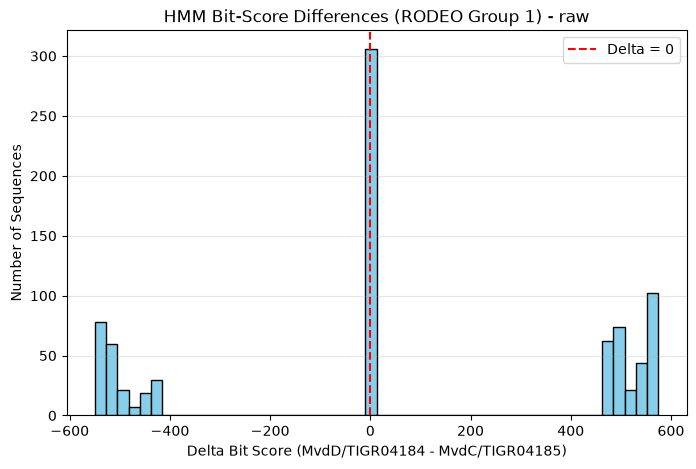

In [7]:
# --- raw histogram (shows the delta=0 artifact) ---
plt.figure(figsize=(8, 5))
plt.hist(df_final["delta"], bins=50, color="skyblue", edgecolor="black")
plt.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Delta = 0")
plt.xlabel("Delta Bit Score (MvdD/TIGR04184 - MvdC/TIGR04185)")
plt.ylabel("Number of Sequences")
plt.title("HMM Bit-Score Differences (RODEO Group 1) - raw")
plt.legend(); plt.grid(axis="y", alpha=0.3)
plt.show()

In [8]:
# --- GA-rule labels ---
labels = []
for _, row in df_final.iterrows():
    passes_C = row["score_04184"] >= 475     # MvdD / ester  -> MdnC-type
    passes_B = row["score_04185"] >= 425     # MvdC / amide  -> MdnB-type   (was 'passes_D' - renamed for clarity)
    if   passes_C and not passes_B: labels.append("MdnC")
    elif passes_B and not passes_C: labels.append("MdnB")
    elif passes_B and passes_C:     labels.append("Both")
    else:                           labels.append("neither")

df_final["label"] = labels          # keep aligned to rodeo_g1
print(Counter(labels))

rodeo_C = [rec for rec, lab in zip(rodeo_g1, labels) if lab == "MdnC"]
SeqIO.write(rodeo_C, DATA / "rodeo_C.fasta", "fasta")
print(f"MdnC-type (ester) sequences written: {len(rodeo_C)}")

Counter({'neither': 306, 'MdnC': 303, 'MdnB': 215})
MdnC-type (ester) sequences written: 303


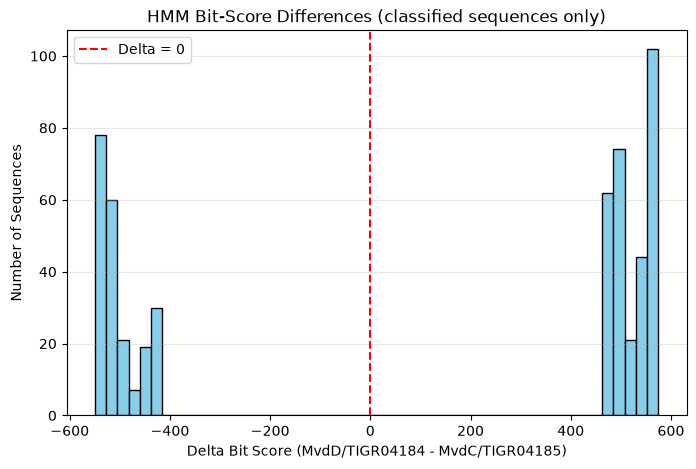

In [9]:
# --- honest histogram: drop the "neither" pile at delta=0 ---
mask = df_final["label"] != "neither"
plt.figure(figsize=(8, 5))
plt.hist(df_final.loc[mask, "delta"], bins=50, color="skyblue", edgecolor="black")
plt.axvline(0, color="red", linestyle="--", linewidth=1.5, label="Delta = 0")
plt.xlabel("Delta Bit Score (MvdD/TIGR04184 - MvdC/TIGR04185)")
plt.ylabel("Number of Sequences")
plt.title("HMM Bit-Score Differences (classified sequences only)")
plt.legend(); plt.grid(axis="y", alpha=0.3)
plt.show()

## B.5b — `neither` diagnostic (what are we discarding?)

`--cut_ga` throws away the scores for `neither` sequences, so to inspect them we re-scan **without** the gate
(`-E 1000` reports essentially everything) into a *separate* table. We then look at the best MvdD score of the
`neither` set. The tiers matter: a sequence can have an MvdD score, or hit only MvdC, or produce no row at all —
`describe()` silently ignores the last two, so we print the tier counts too.

> Interpreting the top of the distribution: scores clustered just under 475 = divergent-but-real ester-formers
> shaved by a hair; scores down in the low hundreds = genuine outsiders. (We found the top cluster was a
> coherent *Chryseobacterium* clade — real ester-formers, but non-microviridin, which foreshadows Section D.)

In [10]:
tbl_ungated = DATA / "rodeo_g1_ungated.tbl"
subprocess.run(
    ["hmmscan", "-E", "1000", "--tblout", str(tbl_ungated), str(hmm_db), str(rodeo_fasta)],
    capture_output=True, text=True, check=True,
)

neither_ids = {rec.id for rec, lab in zip(rodeo_g1, labels) if lab == "neither"}

rows_ung = []
for result in SearchIO.parse(tbl_ungated, "hmmer3-tab"):
    for hit in result:
        rows_ung.append({"query": result.id, "model": hit.id, "bitscore": hit.bitscore})
df_raw_ung = pd.DataFrame(rows_ung)
df_pivot_ung = df_raw_ung.pivot(index="query", columns="model", values="bitscore").reset_index()
df_pivot_ung = df_pivot_ung.rename(columns={"ATPgraspMvdD": "score_04184", "ATPgraspMvdC": "score_04185"})

df_neither = df_pivot_ung[df_pivot_ung["query"].isin(neither_ids)].copy()

print("--- 'neither' MvdD score distribution ---")
print(df_neither["score_04184"].describe())
print("neither total:         ", len(neither_ids))
print("  had >=1 hit:         ", len(df_neither))
print("  had an MvdD score:   ", df_neither["score_04184"].notna().sum())
print("  no hit even at E1000:", len(neither_ids) - len(df_neither))

top_neither_ids = (df_neither.sort_values("score_04184", ascending=False)
                              .head(3)["query"].tolist())
handle = Entrez.efetch(db="protein", id=",".join(top_neither_ids), rettype="gp", retmode="text")
print(handle.read())
handle.close()

--- 'neither' MvdD score distribution ---
count    306.000000
mean     280.683333
std      112.600447
min      108.700000
25%      185.225000
50%      223.400000
75%      411.425000
max      474.800000
Name: score_04184, dtype: float64
neither total:          306
  had >=1 hit:          306
  had an MvdD score:    306
  no hit even at E1000: 0
LOCUS       WP_053326833             334 aa            linear   BCT 30-MAR-2026
DEFINITION  MvdC/MvdD family ATP grasp protein [Chryseobacterium gallinarum].
ACCESSION   WP_053326833
VERSION     WP_053326833.1
KEYWORDS    RefSeq.
SOURCE      Chryseobacterium gallinarum
  ORGANISM  Chryseobacterium gallinarum
            Bacteria; Pseudomonadati; Bacteroidota; Flavobacteriia;
            Flavobacteriales; Weeksellaceae; Chryseobacterium group;
            Chryseobacterium.
REFERENCE   1  (residues 1 to 334)
  AUTHORS   Li,G., Patel,K., Zhang,Y., Pugmire,J.K., Ding,Y. and Bruner,S.D.
  TITLE     Structural and biochemical studies of an iterative ri

## C.1 — Orthogonal validation: RODEO column vs HMM call

`acc2column` (from Section A) tells us whether each ligase sat in the cluster's L1 or L2 slot — a signal from
*genomic context*, completely independent of the sequence-based HMM. If the HMM tracks real biology, L1 should
be overwhelmingly one family and L2 the other. (It came out ~86% clean on the diagonal — strong mutual validation.)

In [11]:
origins = [acc2column.get(rec.id, "Unknown") for rec in rodeo_g1]
pd.crosstab(pd.Series(origins, name="RODEO Column"),
            pd.Series(labels,  name="HMM Call"))

HMM Call,MdnB,MdnC,neither
RODEO Column,,,
L1,40,268,118
L2,175,35,188


## C.2 — Cross-check against the old pairwise-identity method

The method that *failed* the original analysis, kept as a benchmark. It aligns each sequence to a single MdnC
and a single MdnB reference and classifies by which it's more identical to. Expect: it agrees with the HMM on
*direction* wherever it commits, but over-commits on borderline sequences the HMM correctly abstains on — the
precision/recall gap that motivated the whole switch to HMMs.

> Make sure `query_seq` is the **ester/MdnC** reference and `mdnb_seq` the **amide/MdnB** reference (as strings,
> not `SeqRecord`s), or every call inverts.

In [12]:
query_seq = str(CD[0].seq)     # ester / MdnC reference (WP_012265553)
mdnb_seq  = str(CD[1].seq)     # amide / MdnB reference (WP_012265554)

aligner = PairwiseAligner(mode="global")
aligner.substitution_matrix = substitution_matrices.load("BLOSUM62")
aligner.open_gap_score = -11
aligner.extend_gap_score = -1

def percent_identity_ungapped(a, b):
    matches = tot = 0
    for x, y in zip(a, b):
        if x == "-" or y == "-":
            continue
        tot += 1
        matches += (x == y)
    return 100.0 * matches / tot if tot else 0.0

def classify_bc_pairwise(seq, margin=3.0):
    aln_c = aligner.align(seq, query_seq)[0]
    aln_b = aligner.align(seq, mdnb_seq)[0]
    id_to_C = percent_identity_ungapped(aln_c[0], aln_c[1])
    id_to_B = percent_identity_ungapped(aln_b[0], aln_b[1])
    diff = id_to_C - id_to_B
    if   diff >  margin: return "C"
    elif diff < -margin: return "B"
    else:                return "unsure"

pairwise_labels = [classify_bc_pairwise(str(rec.seq)) for rec in rodeo_g1]   # slow: ~1650 global alignments
pd.crosstab(pd.Series(pairwise_labels, name="pairwise"),
            pd.Series(labels,          name="HMM call"))

HMM call,MdnB,MdnC,neither
pairwise,,,
B,211,0,126
C,0,303,109
unsure,4,0,71


## C.3 — α7 residue consensus panel

Does the microviridin consensus at Glu191/Asp192/Asn195 hold across *diverse* cyanobacterial MdnC, and does the
divergent (non-microviridin) clade differ there? We align our MdnC anchor + a diverse cyanobacterial panel +
the top `neither` *Chryseobacterium* sequences, then read the three alignment columns.

**Off-by-one guard.** "Glu191" is PDB author numbering; our anchor sequence must actually carry E/D/N at
0-indexed 190/191/194 for position-based mapping to be valid. We assert it before trusting anything, and the
column mapping is anchored to the reference row (so it auto-adjusts when the alignment changes).

> The residue→column counter is 0-indexed (starts at −1, first residue → 0), matching `target_indices`
> `{190, 191, 194}`. MAFFT preserves input order (no `--reorder`), so the anchor is the first row printed —
> its residues at the three columns **must** read E, D, N or the mapping slipped.

In [39]:
anchor = CD[0]                 # MdnC ester anchor (WP_012265553)

# a DIVERSE cyanobacterial panel (different orders/genera) so the consensus check isn't trivial
extra_ids = {
    "WP_015158320.1", # Chamaesiphon minutus         - Deep-branching divergent Cyanobacteria
    "RCJ32138.1",   # Nostoc punctiforme          - Nostocales
    "BAZ30401.1",   # Cylindrospermum sp.          - a different Nostocalean family
    "BBD53456.1",   # Planktothrix agardhii        - Oscillatoriales
    "RAM51840.1",   # Hapalosiphonaceae cyanobact. - true-branching, deep cyano diversity
    "AKE65548.1",   # Microcystis aeruginosa       - within-genus replicate of the anchor
}
extra_mdnc = [rec for rec in rodeo_g1 if rec.id in extra_ids]

top_ids = df_neither.sort_values("score_04184", ascending=False).head(8)["query"].tolist()
panel = [anchor] + extra_mdnc + [rec for rec in rodeo_g1 if rec.id in top_ids]

panel_in  = DATA / "a7_panel.fasta"
panel_out = DATA / "a7_panel_aln.fasta"
SeqIO.write(panel, panel_in, "fasta")

# off-by-one guard: anchor must carry E/D/N at 0-indexed 190/191/194
s = str(anchor.seq)
assert (s[190], s[191], s[194]) == ("E", "D", "N"), (s[190], s[191], s[194])

# align (L-INS-i: MAFFT's most accurate mode, trivial at this size)
with open(panel_out, "w") as out_f:
    subprocess.run(["mafft", "--localpair", "--maxiterate", "1000", str(panel_in)],
                   stdout=out_f, check=True)

aln = AlignIO.read(panel_out, "fasta")
anchor_row = next(r for r in aln if r.id == anchor.id)

# map residue number -> alignment column (count only non-gap residues in the anchor row)
target_indices = {190, 191, 194}      # 0-indexed E191, D192, N195
a7_cols = []
residue_counter = -1
for index, char in enumerate(str(anchor_row.seq)):
    if char != "-":
        residue_counter += 1
        if residue_counter in target_indices:
            a7_cols.append(index)

print(f"Alignment columns for E191, D192, N195: {a7_cols}\n")
for col in a7_cols:
    print(f"--- column {col} ---")
    for rec in aln:
        if rec.id == anchor.id:
            tag = "  <-- MdnC anchor"
        elif rec.id == "WP_015158320.1":
            tag = "  <-- Chamaesiphon (Deep-branching)"
        else:
            tag = ""
        print(f"  {rec.seq[col]}  {rec.id}{tag}")

Alignment columns for E191, D192, N195: [211, 212, 215]

--- column 211 ---
  E  WP_012265553.1  <-- MdnC anchor
  E  AKE65548.1
  E  BAZ30401.1
  D  BBD53456.1
  E  RAM51840.1
  D  RCJ32138.1
  A  WP_015158320.1  <-- Chamaesiphon (Deep-branching)
  N  WP_053326833.1
  D  WP_056223091.1
  E  WP_089755755.1
  E  WP_123262036.1
  E  WP_149247160.1
  K  WP_149676569.1
  D  WP_168237301.1
  K  WP_179472397.1
--- column 212 ---
  D  WP_012265553.1  <-- MdnC anchor
  D  AKE65548.1
  D  BAZ30401.1
  D  BBD53456.1
  D  RAM51840.1
  D  RCJ32138.1
  D  WP_015158320.1  <-- Chamaesiphon (Deep-branching)
  K  WP_053326833.1
  K  WP_056223091.1
  K  WP_089755755.1
  N  WP_123262036.1
  K  WP_149247160.1
  D  WP_149676569.1
  K  WP_168237301.1
  N  WP_179472397.1
--- column 215 ---
  N  WP_012265553.1  <-- MdnC anchor
  N  AKE65548.1
  H  BAZ30401.1
  N  BBD53456.1
  H  RAM51840.1
  N  RCJ32138.1
  N  WP_015158320.1  <-- Chamaesiphon (Deep-branching)
  E  WP_053326833.1
  E  WP_056223091.1
  E  WP_08

outputhat23=16
treein = 0
compacttree = 0
stacksize: 8176 kb
rescale = 1
All-to-all alignment.
tbfast-pair (aa) Version 7.526
alg=L, model=BLOSUM62, 2.00, -0.10, +0.10, noshift, amax=0.0
0 thread(s)

outputhat23=16
Loading 'hat3.seed' ... 
done.
Writing hat3 for iterative refinement
rescale = 1
Gap Penalty = -1.53, +0.00, +0.00
tbutree = 1, compacttree = 0
Constructing a UPGMA tree ... 
   10 / 15
done.

Progressive alignment ... 
STEP    14 /14 
done.
tbfast (aa) Version 7.526
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
1 thread(s)

minimumweight = 0.000010
autosubalignment = 0.000000
nthread = 0
randomseed = 0
blosum 62 / kimura 200
poffset = 0
niter = 16
sueff_global = 0.100000
nadd = 16
Loading 'hat3' ... done.
rescale = 1

   10 / 15
Segment   1/  1    1- 357
STEP 002-002-1  identical.   
Converged.

done
dvtditr (aa) Version 7.526
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)


Strategy:
 L-INS-i (Probably most accurate, very slow)
 Ite

### Interpreting the panel (grounded in Li et al. 2016, *Nat. Chem. Biol.*)

The pattern is **graded**, and the primary paper predicts it:
- **Asp192 — invariant** across cyanobacterial MdnC, divergent (Lys/Asn) in the *Chryseobacterium* clade. Li 2016:
  *"Asp192 is well conserved among all microviridin macrocyclases."* This is a **specificity-determining position** —
  the load-bearing residue.
- **Glu191 — conserved only as acidic character** (E or D within cyano). Li 2016: *"Glu191 is replaced by an
  aspartate residue"* in most homologs. Its raw ConSurf grade will be intermediate; interpret it as
  physicochemical (charge) conservation, not identity.
- **Asn195 — mostly N but His in the deepest-branching lineages** (Cylindrospermum, Hapalosiphonaceae). A
  lower-constraint, phylogenetically-structured position — report it, don't hide it.

The full ConSurf run quantifies this; here we've previewed it and confirmed the microviridin *consensus* is real,
not a single-sequence artifact.

## D — NEW: taxonomic filter to Cyanobacteria (the decontamination step)

**Why this is required.** The HMM sorts by *chemistry* (ester vs amide), not by *microviridin membership*. The
RODEO Group-1 pool is ~58% non-cyanobacterial (Bacteroidetes-dominated), and those genuine ester-forming
graspetide ligases (*Sorangium*, *Chryseobacterium*, *Blastocatellia*, *Microscilla*, …) pass the MdnC threshold
**and diverge at the α7 residues** — exactly the contamination that flattened the first ConSurf. Percent identity
and HMM thresholds can't separate them; taxonomy can.

We keep only `Cyanobacteria` (microviridin is a cyanobacterial natural product). This roughly halves the set —
which is also convenient, since ~150–200 pre-dedup lands in the ConSurf target range after CD-HIT.

In [14]:
# phylum breakdown of the current MdnC set
print("MdnC set by phylum:")
print(Counter(acc2phylum.get(rec.id, "?") for rec in rodeo_C))

# keep only cyanobacterial MdnC  (spreadsheet uses the OLD name 'Cyanobacteria')
cyano_mdnc = [rec for rec in rodeo_C if acc2phylum.get(rec.id) == "Cyanobacteria"]
SeqIO.write(cyano_mdnc, DATA / "cyano_mdnc.fasta", "fasta")

print(f"\nCyanobacterial MdnC kept: {len(cyano_mdnc)} / {len(rodeo_C)}")

# keep a few non-cyano ester-formers as a labelled OUTGROUP for the tree only (Section F)
outgroup = [rec for rec in rodeo_C if acc2phylum.get(rec.id) != "Cyanobacteria"][:8]
SeqIO.write(outgroup, DATA / "outgroup_ester.fasta", "fasta")
print(f"Outgroup ester-formers saved (tree only, NOT for ConSurf): {len(outgroup)}")

MdnC set by phylum:
Counter({'Cyanobacteria': 172, 'Bacteroidetes': 117, 'Proteobacteria': 12, 'Acidobacteria': 1, 'uncultured': 1})

Cyanobacterial MdnC kept: 172 / 303
Outgroup ester-formers saved (tree only, NOT for ConSurf): 8


In [32]:
noncyano_df = df_final[(df_final["query"].isin([rec.id for rec in rodeo_C])) &
                    (df_final["query"].map(lambda x: acc2phylum.get(x)) != "Cyanobacteria")].copy()

noncyano_df["phylum"] = noncyano_df["query"].map(acc2phylum)

noncyano_df = noncyano_df.sort_values(by = "score_04184", ascending = False)
top_bacteroidetes = noncyano_df[noncyano_df["phylum"] == "Bacteroidetes"].head(6)["query"].tolist()
top_proteo = noncyano_df[noncyano_df["phylum"] == "Proteobacteria"].head(2)["query"].tolist()

outgroup_ids = set(top_bacteroidetes + top_proteo)

outgroup = [rec for rec in rodeo_C if rec.id in outgroup_ids]

SeqIO.write(outgroup, DATA / "outgroup_ester.fasta", "fasta")
print(f"Selected {len(outgroup)} outgroup sequences across {len(set(acc2phylum[r.id] for r in outgroup))} phyla:")
for rec in outgroup:
    print(f"  - {rec.id} | Phylum: {acc2phylum.get(rec.id)} | MvdD Score: {df_final.loc[df_final['query'] == rec.id, 'score_04184'].values[0]:.1f}")


Selected 8 outgroup sequences across 2 phyla:
  - CAN97345.1 | Phylum: Proteobacteria | MvdD Score: 508.2
  - QBA20326.1 | Phylum: Bacteroidetes | MvdD Score: 500.1
  - WP_002703881.1 | Phylum: Bacteroidetes | MvdD Score: 528.7
  - WP_002977594.1 | Phylum: Bacteroidetes | MvdD Score: 502.6
  - WP_012239784.1 | Phylum: Proteobacteria | MvdD Score: 508.2
  - WP_131435241.1 | Phylum: Bacteroidetes | MvdD Score: 501.7
  - WP_149833109.1 | Phylum: Bacteroidetes | MvdD Score: 499.7
  - WP_193544453.1 | Phylum: Bacteroidetes | MvdD Score: 500.1


## E — Merge with the BLAST-window set + deduplicate  *(scaffold)*

Union the cyanobacterial MdnC set with your **BLAST-window** set (already cyanobacterial MvdD-family —
confirm that assumption before trusting it), then **CD-HIT** to remove near-identical sequences. RODEO
over-samples closely related cyanobacterial genomes, so this collapses a lot of redundancy.

> **CD-HIT threshold** (from ConSurf best practice): cluster at **0.90** identity — keep it in the 0.80–0.95 band;
> going below 0.80 strips the diversity ConSurf needs. `-n 5` is the right word size for that identity range.

In [24]:
# loading BLAST-window set
hmm_db = DATA / "mvD hmm files" / "mvd_families.hmm"   # in the setup cell, not just this one
print(hmm_db.exists())                                   # -> True
print((hmm_db.parent / (hmm_db.name + ".h3m")).exists()) # -> True
CHUNK = 200
blast_ids = [line.strip() for line in open(DATA / "blast_focused_window_cyano_accessions.txt") if line.strip()]
blast_window_file = DATA / "blast_window.fasta"
blast_set = []

for i in range(0, len(blast_ids), CHUNK):
    ids = ",".join(blast_ids[i:i+CHUNK])
    h = Entrez.efetch(db = "protein", id = ids, rettype = "fasta", retmode = "text")
    blast_set.extend(SeqIO.parse(h, "fasta"))
    h.close()
    
SeqIO.write(blast_set, blast_window_file, "fasta")

#  confirming each is cyanobacterial
blast_tbl = DATA / "blast_window_hmmscan.tbl"

r = subprocess.run(["hmmscan", "--cut_ga", "--tblout", str(blast_tbl),
                    str(hmm_db), str(blast_window_file)],
                   capture_output=True, text=True, check=True)   

best = {}                      # query -> set of models it hit above GA
for result in SearchIO.parse(blast_tbl, "hmmer3-tab"):
    best[result.id] = {hit.id for hit in result}
valid_blast_ids = {q for q, models in best.items()
                   if "ATPgraspMvdD" in models and "ATPgraspMvdC" not in models}

valid_blast_set = [rec for rec in blast_set if rec.id in valid_blast_ids]
print(f"Original BLAST set: {len(blast_set)}")
print(f"HMM-validated BLAST set: {len(valid_blast_set)}")



True
True
Original BLAST set: 133
HMM-validated BLAST set: 133


In [27]:
import shutil
print(shutil.which("cd-hit"))   

/opt/homebrew/Caskroom/miniforge/base/bin/cd-hit


In [28]:

# 2. union with cyano_mdnc, de-duplicating on rec.id (a sequence may appear in both)
merged = {rec.id: rec for rec in (cyano_mdnc + valid_blast_set)}.values()
SeqIO.write(list(merged), DATA / "microviridin_mdnc_merged.fasta", "fasta")
print("merged (pre-CD-HIT):", len(list(merged)))   # note: 'merged' is a dict_values view

# 3. CD-HIT deduplicate (target: ~50-150 after clustering)
subprocess.run(["cd-hit",
                   "-i", str(DATA / "microviridin_mdnc_merged.fasta"),
                   "-o", str(DATA / "microviridin_mdnc_nr90.fasta"),
                    "-c", "0.90", "-n", "5"], check=True)


# 4. print the final count and confirm it lands in the 50-150 ConSurf range
final_seqs = list(SeqIO.parse(DATA / "microviridin_mdnc_nr90.fasta", "fasta"))
print(f"Final deduplicated sequence count: {len(final_seqs)}")
final_ids = {rec.id for rec in final_seqs}
if anchor.id not in final_ids:
    final_seqs.append(anchor)            # anchor = CD[0], your 5IG9/WP_012265553 record
    SeqIO.write(final_seqs, DATA / "microviridin_mdnc_nr90.fasta", "fasta")
    print(f"Re-inserted anchor; new count: {len(final_seqs)}")

merged (pre-CD-HIT): 279
Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 21:58:32
Command: cd-hit -i ../data/microviridin_mdnc_merged.fasta -o
         ../data/microviridin_mdnc_nr90.fasta -c 0.90 -n 5

Started: Fri Aug  7 17:05:52 2026
                            Output                              
----------------------------------------------------------------
total seq: 279
longest and shortest : 356 and 316
Total letters: 91181
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 0M
Buffer          : 1 X 16M = 16M
Table           : 1 X 65M = 65M
Miscellaneous   : 0M
Total           : 81M

Table limit with the given memory limit:
Max number of representatives: 1689024
Max number of word counting entries: 89804574

comparing sequences from          0  to        279

      279  finished         70  clusters

Approximated maximum memory consumption: 81M
writing new database
writing clustering information
program completed !

Total CPU time 0.04
Final

In [29]:
# Comparing non-duplicate sequences from RODEO vs Blast
SeqIO.write(cyano_mdnc, DATA / "rodeo_only.fasta", "fasta")
subprocess.run(["cd-hit", "-i", str(DATA / "rodeo_only.fasta"),
                "-o", str(DATA / "rodeo_only_nr90.fasta"),
                "-c", "0.90", "-n", "5"], check=True)
rodeo_only = list(SeqIO.parse(DATA / "rodeo_only_nr90.fasta", "fasta"))
print("RODEO-alone clusters:", len(rodeo_only))

Program: CD-HIT, V4.8.1 (+OpenMP), Apr 24 2025, 21:58:32
Command: cd-hit -i ../data/rodeo_only.fasta -o
         ../data/rodeo_only_nr90.fasta -c 0.90 -n 5

Started: Fri Aug  7 17:11:32 2026
                            Output                              
----------------------------------------------------------------
total seq: 172
longest and shortest : 356 and 317
Total letters: 56296
Sequences have been sorted

Approximated minimal memory consumption:
Sequence        : 0M
Buffer          : 1 X 16M = 16M
Table           : 1 X 65M = 65M
Miscellaneous   : 0M
Total           : 81M

Table limit with the given memory limit:
Max number of representatives: 1689149
Max number of word counting entries: 89811208

comparing sequences from          0  to        172

      172  finished         61  clusters

Approximated maximum memory consumption: 81M
writing new database
writing clustering information
program completed !

Total CPU time 0.03
RODEO-alone clusters: 61


## F — Align → trim → tree → readiness → ConSurf  *(scaffold)*

This is where the set is **finally defined** — not by the HMM threshold, but by the monophyletic clade that
contains 5IG9. Two alignment files come out of this section with **different** treatments, and mixing them up is
the main hazard:
- a **trimmed** alignment for the **tree** (trimming sharpens topology and branch support), and
- an **untrimmed, query-anchored** alignment for **ConSurf** (trimming can delete the very columns you're grading).

The non-cyano `outgroup` is included in the **tree** to root it and make the clade boundary visible; it is
**excluded from the ConSurf set**.

### F.1 — MAFFT L-INS-i

Highest-accuracy alignment mode; quality here matters more than the tree algorithm because it feeds everything
downstream. Align the cyanobacterial MdnC set (use the CD-HIT output from Section E) plus the outgroup.

In [33]:
tree_in = DATA / "mdnc_plus_outgroup.fasta"

SeqIO.write(final_seqs + list(outgroup), tree_in, "fasta")  

aln_full = DATA / "mdnc_aln.fasta"
with open(aln_full, "w") as f:
    subprocess.run(["mafft", "--localpair", "--maxiterate", "1000", str(tree_in)], stdout=f, check=True)

outputhat23=16
treein = 0
compacttree = 0
stacksize: 8176 kb
rescale = 1
All-to-all alignment.
tbfast-pair (aa) Version 7.526
alg=L, model=BLOSUM62, 2.00, -0.10, +0.10, noshift, amax=0.0
0 thread(s)

outputhat23=16
Loading 'hat3.seed' ... 
done.
Writing hat3 for iterative refinement
rescale = 1
Gap Penalty = -1.53, +0.00, +0.00
tbutree = 1, compacttree = 0
Constructing a UPGMA tree ... 
   70 / 79
done.

Progressive alignment ... 
STEP    54 /78 
Reallocating..done. *alloclen = 1727
STEP    78 /78 
done.
tbfast (aa) Version 7.526
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
1 thread(s)

minimumweight = 0.000010
autosubalignment = 0.000000
nthread = 0
randomseed = 0
blosum 62 / kimura 200
poffset = 0
niter = 16
sueff_global = 0.100000
nadd = 16
Loading 'hat3' ... done.
rescale = 1

   70 / 79
Segment   1/  1    1- 412
STEP 004-010-1  identical.   
Converged.

done
dvtditr (aa) Version 7.526
alg=A, model=BLOSUM62, 1.53, -0.00, -0.00, noshift, amax=0.0
0 thread(s)


Strate

In [34]:
from Bio import AlignIO
aln = AlignIO.read(aln_full, "fasta")
print(f"{len(aln)} sequences, {aln.get_alignment_length()} columns")
print("anchor present:", any(rec.id == anchor.id for rec in aln))

79 sequences, 389 columns
anchor present: True


### F.2 — Trim  *(for the TREE only — with a guard)*

Trimming (**trimAl** or **ClipKIT** — tools that drop poorly-aligned, gappy alignment columns) stops the tree from
being misled by alignment noise. **Critical caveat:** trimming can delete the columns holding residues
191/192/195 — harmless for the tree, fatal for ConSurf, which grades those exact columns. So trim a *copy* for the
tree, keep `aln_full` untrimmed for ConSurf, and if you ever intend to feed a trimmed MSA to ConSurf, **assert the
target columns survived first**.

`-gt 0.2` (trimAl) keeps columns present in ≥20% of sequences.

In [36]:
# TODO(you):
aln_trim = DATA / "mdnc_aln_trim.fasta"
subprocess.run(["trimal", "-in", str(aln_full), "-out", str(aln_trim), "-gt", "0.2"], check=True)

from Bio import AlignIO
before = AlignIO.read(aln_full, "fasta").get_alignment_length()
after  = AlignIO.read(aln_trim, "fasta").get_alignment_length()
print(f"{before} -> {after} columns  ({after/before:.0%} retained)")

# GUARD (only if you ever trim the ConSurf MSA): re-map E191/D192/N195 into the trimmed alignment exactly as in
# C.3 and assert all three columns are still present before trusting it. For the TREE, trimming them away is fine.

389 -> 334 columns  (86% retained)


### F.3 — FastTree quick preview  *(optional, cheap)*

**FastTree** builds an approximate tree in seconds — a fast look to confirm the microviridin clade separates
cleanly from the outgroup *before* you commit to the slow IQ-TREE run. Its branch support is weaker (local SH-like
values, not real bootstrap), so this is a preview, not the final tree.

In [37]:
# TODO(you):
with open(DATA / "mdnc_fasttree.nwk", "w") as f:
    subprocess.run(["fasttree", str(aln_trim)], stdout=f, check=True)
                   
# # open the .nwk (iTOL or ete3): does 5IG9 sit in a clean clade with the outgroup branching away?
# # if yes, proceed to IQ-TREE; if the clade looks messy, revisit the set before spending the IQ-TREE run.

FastTree Version 2.1.11 Double precision (No SSE3), OpenMP (8 threads)
Alignment: ../data/mdnc_aln_trim.fasta
Amino acid distances: BLOSUM45 Joins: balanced Support: SH-like 1000
Search: Normal +NNI +SPR (2 rounds range 10) +ML-NNI opt-each=1
TopHits: 1.00*sqrtN close=default refresh=0.80
ML Model: Jones-Taylor-Thorton, CAT approximation with 20 rate categories
Initial topology in 0.03 seconds
Refining topology: 25 rounds ME-NNIs, 2 rounds ME-SPRs, 13 rounds ML-NNIs
      0.10 seconds: ME NNI round 9 of 25, 1 of 76 splits
Total branch-length 9.178 after 0.17 sec
      0.24 seconds: ML NNI round 1 of 13, 1 of 76 splits
ML-NNI round 1: LogLk = -19897.967 NNIs 13 max delta 9.59 Time 0.50
      0.50 seconds: Site likelihoods with rate category 1 of 20
      0.61 seconds: Site likelihoods with rate category 18 of 20
Switched to using 20 rate categories (CAT approximation)
Rate categories were divided by 1.037 so that average rate = 1.0
CAT-based log-likelihoods may not be comparable across 

In [38]:
# Checking Fasttree anomaly 
acc2phylum.get("WP_015158320.1")

'Cyanobacteria'

### F.4 — IQ-TREE (final tree) + clade definition

The final, rigorous tree — this is what actually defines your ConSurf set. `-m MFP` = **ModelFinder Plus**
(auto-selects the amino-acid substitution model, e.g. LG+G4 — carry it into ConSurf); `-B 1000` = **ultrafast
bootstrap**; `-alrt 1000` = **SH-aLRT** support. Draw the microviridin clade boundary only at well-supported nodes
(UFBoot ≥ 95 **and** SH-aLRT ≥ 80); confirm 5IG9 sits inside it and the outgroup branches away.

In [42]:
# TODO(you):
tree_prefix = DATA / "iqtree_run"

print(f"Target input path: {aln_trim.resolve()}")
print(f"Input file exists: {aln_trim.exists()}")
assert aln_trim.exists(), f"Error: Could not find {aln_trim}"

print("\nStarting IQ-TREE 2 run (this may take a few minutes)...")
cmd = [
    "iqtree",
    "-s", str(aln_trim),
    "-m", "MFP",
    "-B", "1000",
    "-alrt", "1000",
    "-T", "AUTO",
    "-pre", str(tree_prefix) # Forces all output files to use this prefix/path
]

subprocess.run(cmd, check=True)

final_tree = DATA / "iqtree_run.treefile"
summary_log = DATA / "iqtree_run.iqtree"

print("\nValidating IQ-TREE outputs:")
print(f"Tree generated ({final_tree.name}): {final_tree.exists()}")
print(f"Report generated ({summary_log.name}): {summary_log.exists()}")

assert final_tree.exists(), "Error: IQ-TREE completed, but the .treefile was not found!"

#
# --- define the ConSurf set from the tree ---
# open the .treefile (iTOL or ete3), find the monophyletic clade containing WP_012265553, exclude the outgroup,
# and collect that clade's accession IDs into `clade_ids`:
# clade_records = [rec for rec in cyano_mdnc if rec.id in clade_ids]
# SeqIO.write(clade_records, DATA / "microviridin_clade.fasta", "fasta")

Target input path: /Users/phamchutuanminh/Documents/microviridin-project/data/mdnc_aln_trim.fasta
Input file exists: True

Starting IQ-TREE 2 run (this may take a few minutes)...
IQ-TREE version 3.1.3 for MacOS ARM 64-bit built Jul 26 2026
Developed by Bui Quang Minh, Thomas Wong, Nhan Ly-Trong, Huaiyan Ren
Contributed by Lam-Tung Nguyen, Dominik Schrempf, Chris Bielow,
Olga Chernomor, Michael Woodhams, Diep Thi Hoang, Heiko Schmidt

Host:    Phams-MacBook-Air-2.local (SSE4.2, 8 GB RAM)
Command: iqtree -s ../data/mdnc_aln_trim.fasta -m MFP -B 1000 -alrt 1000 -T AUTO -pre ../data/iqtree_run
Seed:    659805 (Using SPRNG - Scalable Parallel Random Number Generator)
Time:    Sun Aug  9 15:48:42 2026
Kernel:  SSE2 - auto-detect threads (8 CPU cores detected)

Reading alignment file ../data/mdnc_aln_trim.fasta ... Fasta format detected
Reading fasta file: done in 0.000633955 secs using 55.84% CPU
Alignment most likely contains protein sequences
Constructing alignment: done in 0.000468016 sec

### F.5 — Readiness diagnostic  *(run BEFORE you submit to ConSurf)*

A QC gate so you don't waste a ConSurf run. It checks the four things that actually sink a run: **set size**,
**redundancy/diversity**, that the **5IG9 query is present and full-length**, and — most important — the **gap
content of the alignment columns for 191/192/195** (a gappy target column is what triggers a false
"insufficient data" flag). Build the ConSurf MSA from the **untrimmed** alignment restricted to the clade, then diagnose.

In [44]:
# TODO(you): build the ConSurf MSA = the UNTRIMMED alignment restricted to clade sequences (+ the 5IG9 query),
#            then compute the four checks below.
final_seqs = list(SeqIO.parse(DATA / "microviridin_mdnc_nr90.fasta", "fasta"))

clade_ids = {rec.id for rec in final_seqs}        
consurf_records = [rec for rec in AlignIO.read(aln_full, "fasta") if rec.id in clade_ids]

from Bio.Align import MultipleSeqAlignment
consurf_aln = MultipleSeqAlignment(consurf_records)

AlignIO.write(consurf_aln, DATA / "consurf_msa.fasta", "fasta")
consurf_aln = AlignIO.read(DATA / "consurf_msa.fasta", "fasta")

n = len(consurf_aln)

# 1) SIZE  -- is n in the 50-150 target band?
print(f"sequences: {n}", "OK" if 50 <= n <= 150 else "OUT OF RANGE")

# 2) QUERY PRESENT -- is the 5IG9 / WP_012265553 anchor in the alignment and full length?

assert anchor.id in {rec.id for rec in consurf_aln}, f"Anchor {anchor.id} missing!"


# 3) TARGET-COLUMN OCCUPANCY (the important one) -- map E191/D192/N195 to columns (same counter as C.3),
#    then for each, the fraction of NON-gap characters. ConSurf treats <6 non-gapped residues as unreliable,
#    and gappy columns drag the grade, so flag anything sparse:
target_indices = {190, 191, 194}     
a7_cols = []
residue_counter = -1
anchor_row = next(r for r in consurf_aln if r.id == anchor.id)

for index, char in enumerate(str(anchor_row.seq)):
    if char != "-":
        residue_counter += 1
        if residue_counter in target_indices:
            a7_cols.append(index)
            
assert len(a7_cols) == 3, f"Expected 3 target columns, got {a7_cols} - anchor may be truncated or mis-numbered"

print(f"Alignment columns for E191, D192, N195: {a7_cols}\n")
for col in a7_cols:
    print(f"--- column {col} (anchor residue = {anchor_row.seq[col]}) ---")
    for rec in consurf_aln:
        tag = "  <-- MdnC anchor" if rec.id == anchor.id else ""
        print(f"  {rec.seq[col]}  {rec.id}{tag}")

for col in a7_cols:
    occ = sum(rec.seq[col] != "-" for rec in consurf_aln) / n
    print(f"col {col}: {occ:.0%} occupied", "  <-- GAPPY" if occ < 0.5 else "")

# 4) PHYLUM SANITY -- confirm every clade sequence is Cyanobacteria via acc2phylum (no contamination leaked back).
leaks = [r.id for r in consurf_aln if acc2phylum.get(r.id) not in (None, "Cyanobacteria")]
print("non-cyano leaks:", leaks or "none")

sequences: 71 OK
Alignment columns for E191, D192, N195: [218, 219, 222]

--- column 218 (anchor residue = E) ---
  D  AGH69798.1
  E  AKE65548.1
  E  AVK43357.1
  E  BAZ30401.1
  E  OWY65425.1
  E  RAM51840.1
  D  WP_002771814.1
  S  WP_006509130.1
  E  WP_008184760.1
  E  WP_012625821.1
  D  WP_013324781.1
  E  WP_015119481.1
  A  WP_015158320.1
  E  WP_015199859.1
  E  WP_017315239.1
  K  WP_017717761.1
  A  WP_017748605.1
  E  WP_019494991.1
  E  WP_026732077.1
  E  WP_027403952.1
  E  WP_036480469.1
  A  WP_038296423.1
  A  WP_163518793.1
  E  WP_041034271.1
  E  WP_048871254.1
  D  WP_062289145.1
  D  WP_066379781.1
  E  WP_069068280.1
  E  WP_089130961.1
  D  WP_096559345.1
  E  WP_096603686.1
  D  WP_096621680.1
  E  WP_096637302.1
  E  WP_096642753.1
  A  WP_096656004.1
  E  WP_096685052.1
  E  WP_096691285.1
  E  WP_096692552.1
  E  WP_100898894.1
  E  WP_127082104.1
  D  WP_155748416.1
  E  WP_162395608.1
  N  WP_167721282.1
  E  WP_169216726.1
  D  WP_169262875.1
  E  WP_17

### ConSurf run checklist
- **Input:** the **untrimmed**, query-anchored clade MSA (external-MSA upload), ~50–150 sequences, CD-HIT ≤ 0.95.
- **Method:** empirical Bayesian; substitution model = whatever ModelFinder chose in F.4.
- **After the run, check the three residues on 5IG9:**
  - Confirm none of 191/192/195 is flagged **"insufficient data"** (light yellow: <6 non-gapped residues, or a
    confidence interval spanning ≥4 grades). If they are, F.5 should already have warned you (gappy column).
  - Expect **Asp192 → grade 9** (invariant, high confidence).
  - Expect **Glu191 → intermediate** (identity varies E/D though charge is conserved) — add a physicochemical view.
  - Expect **Asn195 → intermediate/variable** (N→H in deep lineages).
- **Sensitivity check:** confirm Asp192's grade is robust to two or three reasonable clade-boundary choices — that
  robustness is your strongest defense against an "artifact" critique.